# CREB One-Stop SPT Demo

This notebook demonstrates a minimal reproducible One-Stop SPT workflow for the CREB example dataset using representative raw-frame images and precomputed localization/trajectory tables provided in `test_data/`. Because the original raw time-lapse TIFF stack is 4.1 GB and exceeds GitHub file-size limits, it is not included in this repository.Therefore, numerical outputs such as RoC values and motion-state fractions may differ from the full manuscript analysis.

The demo performs the following steps:

1. Load a representative raw-frame image and matched processed inputs
2. Inspect localization/render/scatter inputs
3. Run MaU-Net nuclear segmentation
4. Filter localizations or trajectories by the nuclear mask
5. Reconstruct trajectories and compute RoC
6. Classify trajectories by local density
7. Save intermediate outputs


## 1. Imports and Paths


In [15]:
import os
import sys
from pathlib import Path
from collections import Counter, defaultdict

# Keep matplotlib caches inside the project/session to avoid permission issues.
os.environ.setdefault("MPLCONFIGDIR", str(Path(".matplotlib_cache").resolve()))
os.environ.setdefault("NO_ALBUMENTATIONS_UPDATE", "1")

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from scipy.ndimage import gaussian_filter
from scipy.spatial import cKDTree

PROJECT_ROOT = Path.cwd()
TEST_DATA = PROJECT_ROOT / "test_data"
OUTPUT_DIR = TEST_DATA / "demo_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

# Make local One-Stop SPT modules importable.
sys.path.insert(0, str(PROJECT_ROOT / "SPTpy"))
from unet_attention_model import MultiFusionAttentionUNet
from track_processor import TrackProcessor, TrackProcessorConfig
from msd_analyzer import MSDAnalyzer, MSDAnalyzerConfig
from radius_calculator import RadiusOfConfinementCalculator, RadiusCalculatorConfig

RAW_FRAME_FALLBACK = TEST_DATA / "SMI-293T-CREB-1-JF549_2D_561nm_200mw_10ms_active_64_pos1.png"
LOCS_PATH = TEST_DATA / "SMI-293T-CREB-1-JF549_2D_561nm_200mw_10ms_active_64_pos1_locs.txt"
RENDER_IMAGE_PATH = TEST_DATA / "SMI-293T-CREB-1-JF549_2D_561nm_200mw_10ms_active_64.png"
SCATTER_IMAGE_PATH = TEST_DATA / "SMI-293T-CREB-1-JF549_2D_561nm_200mw_10ms_active_64_scatter_plot.png"
TRACK_TABLE_PATH = TEST_DATA / "SMI-293T-CREB-1-JF549_2D_561nm_200mw_10ms_active_64_pos1_table.txt"
MODEL_PATH = TEST_DATA / "MaU-Net.pth"

print(f"Project root: {PROJECT_ROOT}")
print(f"CUDA available: {torch.cuda.is_available()}")


Project root: /Users/liaoshasha/PycharmProjects/SPTpy
CUDA available: False


## 2. Load Representative Raw Frame

The full raw time-lapse TIFF stack is not included because it exceeds GitHub file-size limits. This demo uses a representative raw-frame PNG for visualization and MaU-Net input, together with precomputed localization and trajectory tables for the downstream workflow.


In [2]:
def normalize_for_display(img, p_low=1, p_high=99.8):
    lo, hi = np.percentile(img, (p_low, p_high))
    if hi <= lo:
        lo, hi = float(np.min(img)), float(np.max(img) or 1)
    return np.clip((img - lo) / (hi - lo), 0, 1)

raw_frame = cv2.imread(str(RAW_FRAME_FALLBACK), cv2.IMREAD_GRAYSCALE)
if raw_frame is None:
    raise FileNotFoundError(f"Missing representative raw frame: {RAW_FRAME_FALLBACK}")

raw_stack = raw_frame[np.newaxis, ...].astype(np.float32)
n_frames, H, W = raw_stack.shape
print(f"Loaded representative raw frame from: {RAW_FRAME_FALLBACK.name}")
print(f"Stack dimensions used for demo: frames={n_frames}, height={H}, width={W}")


Loaded representative raw frame from: SMI-293T-CREB-1-JF549_2D_561nm_200mw_10ms_active_64_pos1.png
Stack dimensions used for demo: frames=1, height=320, width=320


## 3. Localization Table and Render/Scatter Inputs

For the full One-Stop SPT GUI workflow, raw stacks are localized using the **Batch Localization** or **LOC ALL** functions. The resulting localization table is exported as a tab-delimited TXT file. This notebook loads the provided localization table together with the matched render and scatter images in `test_data/`, because MaU-Net expects the same three-channel input style used during model training.


In [16]:
def load_localization_table(path):
    df = pd.read_csv(path, sep="\t")
    required = {"frame_idx", "x_coord", "y_coord"}
    if not required.issubset(df.columns):
        raise ValueError(f"Localization table must contain columns: {sorted(required)}")
    return df

locs = load_localization_table(LOCS_PATH)
print(locs.head())
print(f"Loaded {len(locs):,} localizations from {LOCS_PATH.name}")


   particle_idx  frame_idx     y_coord     x_coord      alpha      Sig2  \
0             0          0   46.339596  125.337800  12.731640  2.174391   
1             1          0   61.020697   70.494189  17.929731  1.900292   
2             2          0   89.749644  125.361202  11.527386  2.353004   
3             3          0  148.263361  257.089142   7.286346  1.907834   
4             4          0  153.195748  229.569349  10.110591  2.255851   

      offset     r  result_ok  
0  76.087002  1.03          1  
1  75.973082  1.03          1  
2  75.576903  1.03          1  
3  76.887382  1.03          1  
4  76.014437  1.03          1  
Loaded 390,971 localizations from SMI-293T-CREB-1-JF549_2D_561nm_200mw_10ms_active_64_pos1_locs.txt


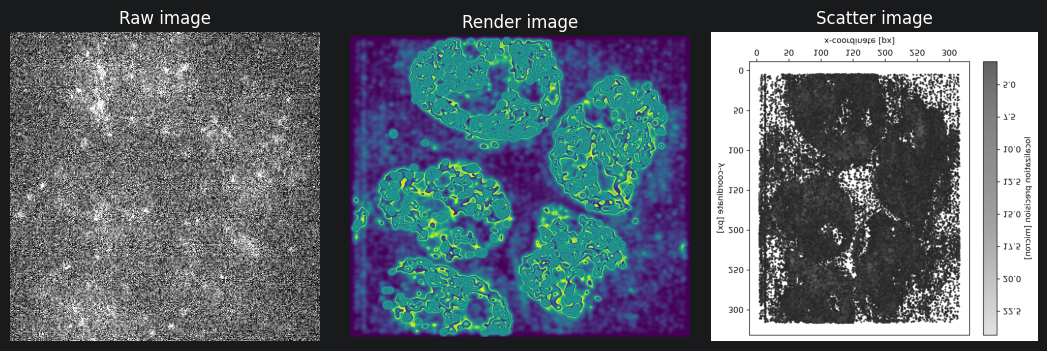

Loaded matched raw image from: SMI-293T-CREB-1-JF549_2D_561nm_200mw_10ms_active_64_pos1.png
Loaded matched render image from: SMI-293T-CREB-1-JF549_2D_561nm_200mw_10ms_active_64.png
Loaded matched scatter image from: SMI-293T-CREB-1-JF549_2D_561nm_200mw_10ms_active_64_scatter_plot.png
Saved demo render image to: /Users/liaoshasha/PycharmProjects/SPTpy/test_data/demo_outputs/demo_render_image.png
Saved demo scatter image to: /Users/liaoshasha/PycharmProjects/SPTpy/test_data/demo_outputs/demo_scatter_plot.png


In [17]:
def to_uint8_view(img, p_low=1, p_high=99):
    arr = np.asarray(img)
    lo, hi = np.percentile(arr, (p_low, p_high))
    if hi <= lo:
        lo, hi = float(arr.min()), float(arr.max() or 1)
    return np.clip((arr - lo) * 255.0 / (hi - lo), 0, 255).astype(np.uint8)


def read_gray_image(path):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Missing image: {path}")
    return img

# The MaU-Net checkpoint was trained with matched raw/render/scatter inputs.
# Use the provided raw PNG plus matched render/scatter PNG files instead of
# regenerating simplified density maps here; otherwise the input distribution
# changes and the mask can drift.
raw_input_img = read_gray_image(RAW_FRAME_FALLBACK)
raw_v = to_uint8_view(raw_input_img)
render_img = read_gray_image(RENDER_IMAGE_PATH)
scatter_img = read_gray_image(SCATTER_IMAGE_PATH)
rend_v = to_uint8_view(render_img)
scat_v = np.flipud(to_uint8_view(scatter_img))

render_png = OUTPUT_DIR / "demo_render_image.png"
scatter_png = OUTPUT_DIR / "demo_scatter_plot.png"
cv2.imwrite(str(render_png), rend_v)
cv2.imwrite(str(scatter_png), scat_v)

fig, axes = plt.subplots(1, 3, figsize=(10.8, 3.5))
axes[0].imshow(raw_v, cmap="gray")
axes[0].set_title("Raw image")
axes[1].imshow(rend_v, cmap="viridis")
axes[1].set_title("Render image")
axes[2].imshow(scat_v, cmap="gray")
axes[2].set_title("Scatter image")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Loaded matched raw image from: {RAW_FRAME_FALLBACK.name}")
print(f"Loaded matched render image from: {RENDER_IMAGE_PATH.name}")
print(f"Loaded matched scatter image from: {SCATTER_IMAGE_PATH.name}")
print(f"Saved demo render image to: {render_png}")
print(f"Saved demo scatter image to: {scatter_png}")


## 4. MaU-Net Nuclear Segmentation

The model takes three input channels: raw grayscale image, rendered localization-density image, and scatter image. The pretrained checkpoint is loaded from `test_data/MaU-Net.pth`.


In [18]:
USE_GPU = True
THRESHOLD = 0.35

device = torch.device("cuda" if USE_GPU and torch.cuda.is_available() else "cpu")
model = MultiFusionAttentionUNet().to(device)
state = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state)
model.eval()

# Resize the matched three-channel input to the model input size.
target = (320, 320)
t1 = cv2.resize(raw_v, target) / 255.0
t2 = cv2.resize(rend_v, target) / 255.0
t3 = cv2.resize(scat_v, target) / 255.0

input_tensor = torch.from_numpy(np.stack([t1, t2, t3], axis=0)).unsqueeze(0).float().to(device)

with torch.no_grad():
    logits = model(input_tensor)[0, 0]
    prob = torch.sigmoid(logits).cpu().numpy()

mask_320 = prob > THRESHOLD
mask_full = cv2.resize(mask_320.astype(np.uint8), (W, H), interpolation=cv2.INTER_NEAREST).astype(bool)
mask_path = OUTPUT_DIR / "demo_segmentation_mask.npy"
np.save(mask_path, mask_full)
print(f"Saved segmentation mask to: {mask_path}")


Saved segmentation mask to: /Users/liaoshasha/PycharmProjects/SPTpy/test_data/demo_outputs/demo_segmentation_mask.npy


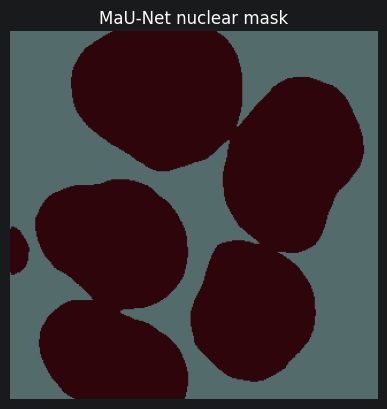

Saved MaU-Net mask visualization to: /Users/liaoshasha/PycharmProjects/SPTpy/test_data/demo_outputs/demo_maunet_mask_visualization.png


In [19]:
# Visualize only the final MaU-Net nuclear mask.
mask_rgb = np.zeros((H, W, 3), dtype=np.float32)
mask_rgb[..., :] = np.array([0.33, 0.42, 0.42])  # muted gray-green background
mask_rgb[mask_full] = np.array([0.18, 0.02, 0.04])  # dark red nuclear mask

fig, ax = plt.subplots(1, 1, figsize=(4.2, 4.2))
ax.imshow(mask_rgb)
ax.set_title("MaU-Net nuclear mask")
ax.axis("off")

plt.tight_layout()
mask_preview_png = OUTPUT_DIR / "demo_maunet_mask_visualization.png"
fig.savefig(mask_preview_png, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved MaU-Net mask visualization to: {mask_preview_png}")


## 5. Nuclear-Mask Filtering

The example trajectory table is filtered by the predicted nuclear mask. The filtered output is saved as a tab-delimited TXT file for downstream analysis.


In [20]:
tracks_raw = np.loadtxt(TRACK_TABLE_PATH, delimiter="\t")
# Expected columns in the provided trajectory table: x, y, frame, track_id, ...
x = np.clip(tracks_raw[:, 0].astype(int), 0, W - 1)
y = np.clip(tracks_raw[:, 1].astype(int), 0, H - 1)
inside = mask_full[y, x]
tracks_nuclear = tracks_raw[inside]

filtered_out = OUTPUT_DIR / "demo_nuclear_filtered_table.txt"
np.savetxt(filtered_out, tracks_nuclear, delimiter="\t", fmt="%.6f")
print(f"Input rows: {len(tracks_raw):,}")
print(f"Rows inside nuclear mask: {len(tracks_nuclear):,}")
print(f"Saved nuclear-filtered table to: {filtered_out}")


Input rows: 390,894
Rows inside nuclear mask: 375,491
Saved nuclear-filtered table to: /Users/liaoshasha/PycharmProjects/SPTpy/test_data/demo_outputs/demo_nuclear_filtered_table.txt


## 6. Spot-On Kinetic Modeling

This section provides a compact Spot-On example using the filtered trajectory table. The trajectories are converted into the `trackedPar` structure used by the integrated Spot-On/fastSPT backend, jump-length histograms are computed across multiple time intervals, and a two-state diffusion model is fitted to the empirical jump-length distributions.


In [21]:
import importlib.util

# NumPy 2 compatibility for the bundled fastSPT implementation.
if not hasattr(np, "float_"):
    np.float_ = np.float64

fastspt_path = PROJECT_ROOT / "SPTpy" / "spoton_core" / "fastspt.py"
spec = importlib.util.spec_from_file_location("fastspt_demo", fastspt_path)
fastspt = importlib.util.module_from_spec(spec)
spec.loader.exec_module(fastspt)

# Use nuclear-filtered trajectories when available. If the mask is too strict in a
# small demo subset, fall back to the provided trajectory table so the kinetic
# modeling example remains executable.
spoton_table = tracks_nuclear if len(tracks_nuclear) >= 100 else tracks_raw
if spoton_table is tracks_raw:
    print("Using the unfiltered trajectory table for the Spot-On demo because too few rows remained after mask filtering.")

PIXEL_SIZE_UM = 0.109
DT_S = 0.01
GAPS_ALLOWED = 1
MAX_ADJACENT_FRAME_JUMP = GAPS_ALLOWED + 1
SPOTON_TIMEPOINTS = 8
MIN_SPOTON_SEGMENT_LEN = SPOTON_TIMEPOINTS


def to_trackedPar(table, pixel_size_um, max_adjacent_frame_jump=2, min_segment_length=8):
    """Convert [x, y, frame, track_id] rows to fastSPT trackedPar format.

    The bundled fastSPT implementation assumes that jumps do not exceed the
    configured gap window. Some reconstructed trajectories contain longer
    frame gaps, so we split such tracks into shorter continuous segments for
    this demo instead of letting those jumps index outside TransLengths.
    """
    track_dict = defaultdict(list)
    for row in table[:, :4]:
        x_px, y_px, frame, tid = row
        track_dict[int(tid)].append((x_px * pixel_size_um, y_px * pixel_size_um, int(frame)))

    trackedPar = []
    split_segments = 0
    for pts in track_dict.values():
        pts = sorted(pts, key=lambda p: p[2])
        segment = []
        last_frame = None

        for pt in pts:
            frame = pt[2]
            if last_frame is not None and (frame - last_frame) > max_adjacent_frame_jump:
                if len(segment) >= min_segment_length:
                    xy = np.array([[p[0], p[1]] for p in segment], dtype=float)
                    frames = np.array([[p[2] for p in segment]], dtype=int)
                    trackedPar.append([xy, None, frames])
                    split_segments += 1
                segment = []
            segment.append(pt)
            last_frame = frame

        if len(segment) >= min_segment_length:
            xy = np.array([[p[0], p[1]] for p in segment], dtype=float)
            frames = np.array([[p[2] for p in segment]], dtype=int)
            trackedPar.append([xy, None, frames])

    return trackedPar, split_segments

trackedPar, split_segments = to_trackedPar(
    spoton_table,
    PIXEL_SIZE_UM,
    max_adjacent_frame_jump=MAX_ADJACENT_FRAME_JUMP,
    min_segment_length=MIN_SPOTON_SEGMENT_LEN,
)
print(f"Trajectories/segments used for Spot-On demo: {len(trackedPar):,}")
print(f"Minimum segment length for Spot-On demo: {MIN_SPOTON_SEGMENT_LEN} frames")
print(f"Segments created after splitting long frame gaps: {split_segments:,}")


Trajectories/segments used for Spot-On demo: 5,848
Minimum segment length for Spot-On demo: 8 frames
Segments created after splitting long frame gaps: 1


In [22]:
# Compute empirical jump-length distributions across multiple time intervals.
HistVecJumps, JumpProb, spoton_meta = fastspt.compute_jump_length_distribution(
    trackedPar,
    CDF=False,
    useEntireTraj=False,
    TimePoints=SPOTON_TIMEPOINTS,
    GapsAllowed=GAPS_ALLOWED,
    JumpsToConsider=4,
    MaxJump=1.25,
    BinWidth=0.02,
)

# Fit a minimal two-state Spot-On model.
# This demonstration uses PDF fitting without Z correction for speed and robustness.
np.random.seed(1)
LB = [0.05, 0.0001, 0.01, 0.01]   # D_free, D_bound, F_bound, sigma
UB = [10.0, 0.1, 0.99, 0.075]

fit = fastspt.fit_jump_length_distribution(
    JumpProb,
    JumpProb,
    HistVecJumps,
    HistVecJumps,
    LB=LB,
    UB=UB,
    LocError=None,
    iterations=1,
    dT=DT_S,
    dZ=0.7,
    ModelFit=1,
    a=0,
    b=0,
    fit2states=True,
    fitSigma=True,
    useZcorr=False,
    verbose=False,
    solverparams={"ftol": 1e-8, "xtol": 1e-8},
)

import warnings

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=RuntimeWarning, message="invalid value encountered in divide")
    sim_pdf = fastspt.generate_jump_length_distribution(
        fit.params,
        JumpProb=JumpProb,
        r=HistVecJumps,
        LocError=fit.params["sigma"].value,
        dT=DT_S,
        dZ=0.7,
        a=0,
        b=0,
        fit2states=True,
        norm=True,
        useZcorr=False,
    )
sim_pdf = np.nan_to_num(sim_pdf, nan=0.0, posinf=0.0, neginf=0.0)

spoton_params = {
    "D_free_um2_s": fit.params["D_free"].value,
    "D_bound_um2_s": fit.params["D_bound"].value,
    "F_bound": fit.params["F_bound"].value,
    "sigma_um": fit.params["sigma"].value,
    "fit_error": getattr(fit.params, "ssq2", np.nan),
}

spoton_out = OUTPUT_DIR / "demo_spoton_2state_fit.txt"
pd.DataFrame([spoton_params]).to_csv(spoton_out, sep="	", index=False)
print(pd.DataFrame([spoton_params]))
print(f"Saved Spot-On fit parameters to: {spoton_out}")


Number of frames: 20000, number of localizations: 163531
   D_free_um2_s  D_bound_um2_s   F_bound  sigma_um  fit_error
0      0.256376       0.006532  0.723156  0.029963   0.000004
Saved Spot-On fit parameters to: /Users/liaoshasha/PycharmProjects/SPTpy/test_data/demo_outputs/demo_spoton_2state_fit.txt


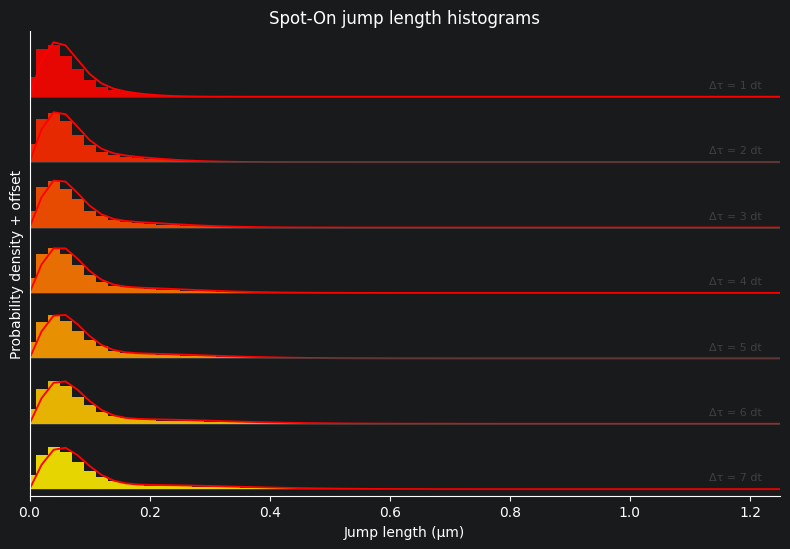

Saved stacked Spot-On histogram plot to: /Users/liaoshasha/PycharmProjects/SPTpy/test_data/demo_outputs/demo_spoton_jump_length_histograms.png


In [24]:
# Plot Spot-On-style jump-length histograms and the fitted two-state model.
n_lags = min(JumpProb.shape[0], sim_pdf.shape[0])
colors = plt.cm.autumn(np.linspace(0.02, 0.92, n_lags))
max_height = max(np.nanmax(JumpProb[:n_lags]), np.nanmax(sim_pdf[:n_lags]))
offset_step = max_height * 1.20

fig, ax = plt.subplots(figsize=(8.0, 5.6))
for i in range(n_lags):
    offset = (n_lags - 1 - i) * offset_step
    empirical = JumpProb[i]
    fitted = sim_pdf[i]

    ax.fill_between(
        HistVecJumps,
        offset,
        empirical + offset,
        step="mid",
        color=colors[i],
        alpha=0.90,
        linewidth=0,
    )
    ax.plot(HistVecJumps, fitted + offset, color="red", lw=1.35)
    ax.axhline(offset, color="0.25", lw=0.60)
    ax.text(
        1.22,
        offset + offset_step * 0.18,
        f"Δτ = {i + 1} dt",
        ha="right",
        va="center",
        fontsize=8,
        color="0.25",
    )

ax.set_title("Spot-On jump length histograms")
ax.set_xlabel("Jump length (µm)")
ax.set_ylabel("Probability density + offset")
ax.set_xlim(0, 1.25)
ax.set_ylim(-offset_step * 0.10, n_lags * offset_step)
ax.set_yticks([])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
stacked_png = OUTPUT_DIR / "demo_spoton_jump_length_histograms.png"
fig.savefig(stacked_png, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved stacked Spot-On histogram plot to: {stacked_png}")


## 7. Trajectory Reconstruction and RoC Analysis

The filtered trajectory table is reconstructed into per-track arrays, MSD curves are computed, and Radius of Confinement (RoC) values are estimated using the One-Stop SPT analysis modules.


In [25]:
track_config = TrackProcessorConfig(
    track_length_cutoff=5,
    acquisition_time=0.01,  # seconds per frame for CREB demo
    pixel_size=0.109,       # micrometers per pixel
)
processor = TrackProcessor(track_config)
tracks = processor.reconstruct_tracks(tracks_nuclear)
print(f"Valid reconstructed tracks: {len(tracks):,}")

msd_analyzer = MSDAnalyzer(MSDAnalyzerConfig())
msd_data = msd_analyzer.compute_msd(tracks)

roc_calculator = RadiusOfConfinementCalculator(RadiusCalculatorConfig())
roc_data = roc_calculator.compute_radius_of_confinement(msd_data)
roc_values_nm_raw = np.array([d["radius_confinement"] for d in roc_data]) * 1000.0
roc_values_nm_raw = roc_values_nm_raw[np.isfinite(roc_values_nm_raw)]

# The RoC model is intended to quantify confined diffusion. Values outside a
# predefined valid range are treated as unreliable fits or non-confined tracks,
# rather than as biologically meaningful confinement radii.
ROC_VALID_MAX_NM = 500.0
valid_roc_mask = (roc_values_nm_raw > 0) & (roc_values_nm_raw <= ROC_VALID_MAX_NM)
roc_values_nm = roc_values_nm_raw[valid_roc_mask]

roc_out = OUTPUT_DIR / "demo_RoC_values_nm.txt"
np.savetxt(roc_out, roc_values_nm, fmt="%.6f")
print(f"Total RoC fits: {len(roc_values_nm_raw):,}")
print(f"Valid confined RoC fits (0-{ROC_VALID_MAX_NM:.0f} nm): {len(roc_values_nm):,}")
print(f"Excluded unreliable/non-confined fits: {len(roc_values_nm_raw) - len(roc_values_nm):,}")
print(f"Saved valid RoC values to: {roc_out}")


Reconstructing tracks (optimized)...
Reconstructed 10642 valid tracks in 0.10s
Valid reconstructed tracks: 10,642
Computing Mean Square Displacement...
Computed MSD for 10642 tracks
Computing Radius of Confinement...
Computed Radius of Confinement for 6933 tracks
Total RoC fits: 6,933
Valid confined RoC fits (0-500 nm): 3,639
Excluded unreliable/non-confined fits: 3,294
Saved valid RoC values to: /Users/liaoshasha/PycharmProjects/SPTpy/test_data/demo_outputs/demo_RoC_values_nm.txt


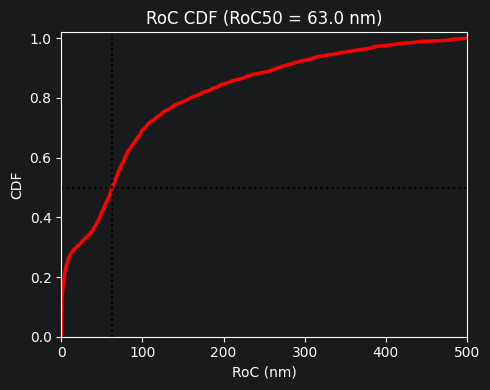

Saved RoC CDF plot to: /Users/liaoshasha/PycharmProjects/SPTpy/test_data/demo_outputs/demo_RoC_CDF.png


In [12]:
if len(roc_values_nm) > 0:
    from scipy.interpolate import PchipInterpolator

    xs = np.sort(roc_values_nm)
    cdf = np.arange(1, len(xs) + 1) / len(xs)
    roc50 = np.percentile(roc_values_nm, 50)

    # Smooth the empirical CDF for visualization using monotonic interpolation.
    # RoC50 is still computed from the original filtered RoC values.
    unique_xs, unique_idx = np.unique(xs, return_index=True)
    cdf_unique = cdf[unique_idx]
    if len(unique_xs) >= 4:
        smooth_x = np.linspace(unique_xs.min(), unique_xs.max(), 600)
        smooth_cdf = PchipInterpolator(unique_xs, cdf_unique)(smooth_x)
        smooth_cdf = np.clip(smooth_cdf, 0, 1)
    else:
        smooth_x, smooth_cdf = xs, cdf

    plt.figure(figsize=(5, 4))
    plt.plot(smooth_x, smooth_cdf, color="red", lw=2.5)
    plt.axhline(0.5, color="black", ls=":")
    plt.axvline(roc50, color="black", ls=":")
    plt.xlim(0, ROC_VALID_MAX_NM)
    plt.ylim(0, 1.02)
    plt.xlabel("RoC (nm)")
    plt.ylabel("CDF")
    plt.title(f"RoC CDF (RoC50 = {roc50:.1f} nm)")
    plt.tight_layout()
    roc_cdf_png = OUTPUT_DIR / "demo_RoC_CDF.png"
    plt.savefig(roc_cdf_png, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved RoC CDF plot to: {roc_cdf_png}")
else:
    print("No valid RoC values were computed. Check the filtered table and fit settings.")


## 8. Motion-State Classification

Trajectories are classified by local molecular density using the default CREB settings: 80 nm neighborhood radius and 60-neighbor threshold.


In [26]:
PIXEL_SIZE_NM = 109.0
RADIUS_THRESHOLD_NM = 80.0
COUNT_THRESHOLD = 60

MAIN_CATEGORIES = [
    "Free trajectory",
    "Condensate trajectory",
    "Condensate to free",
    "Free to condensate",
]
OTHER_LABEL = "Other"


def label_in_out_from_array(data, pixel_size_nm, radius_threshold_nm, count_threshold):
    data = np.asarray(data[:, :4], dtype=float).copy()
    pixel_um = pixel_size_nm / 1000.0
    data[:, 0] *= pixel_um
    data[:, 1] *= pixel_um

    coords = data[:, :2]
    tree = cKDTree(coords)
    r_um = radius_threshold_nm / 1000.0
    neighbors = tree.query_ball_point(coords, r=r_um)
    counts = np.array([len(nbs) for nbs in neighbors])
    inside = counts > count_threshold

    traj_dict = defaultdict(list)
    for idx, (_, _, frame, tid) in enumerate(data):
        traj_dict[int(tid)].append(idx)

    traj_labels = {}
    for tid, idxs in traj_dict.items():
        idxs_sorted = sorted(idxs, key=lambda i: data[i, 2])
        traj_labels[tid] = inside[idxs_sorted]
    return traj_labels


def classify_traj(states):
    states = np.asarray(states, dtype=bool)
    if states.size == 0:
        return OTHER_LABEL
    if states.all():
        return "Condensate trajectory"
    if not states.any():
        return "Free trajectory"
    if states[0] and not states[-1]:
        return "Condensate to free"
    if (not states[0]) and states[-1]:
        return "Free to condensate"
    return OTHER_LABEL

labels = label_in_out_from_array(
    tracks_nuclear,
    pixel_size_nm=PIXEL_SIZE_NM,
    radius_threshold_nm=RADIUS_THRESHOLD_NM,
    count_threshold=COUNT_THRESHOLD,
)

stats = Counter(classify_traj(v) for v in labels.values())

# Report only the four main motion-state categories, matching the manuscript summary.
# Trajectories classified as "Other" are excluded from the denominator.
total_main = sum(stats[c] for c in MAIN_CATEGORIES)
summary = pd.DataFrame({
    "Category": MAIN_CATEGORIES,
    "Count": [stats[c] for c in MAIN_CATEGORIES],
})
summary["Proportion"] = summary["Count"] / max(total_main, 1)

print(f"Other trajectories excluded from summary: {stats[OTHER_LABEL]}")
summary


Other trajectories excluded from summary: 2165


,Category,Count,Proportion
0,Free trajectory,123317,0.815055
1,Condensate trajectory,24778,0.163768
2,Condensate to free,1599,0.010568
3,Free to condensate,1605,0.010608


Saved motion-state summary to: /Users/liaoshasha/PycharmProjects/SPTpy/test_data/demo_outputs/demo_motion_state_summary.txt


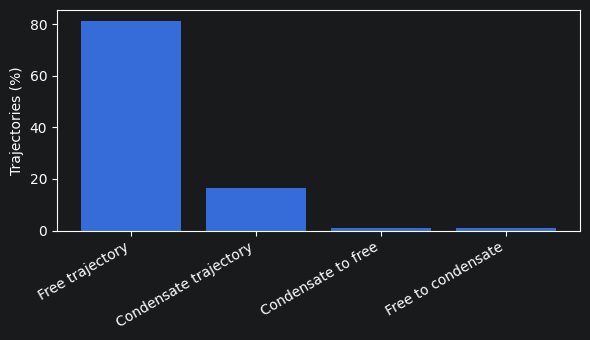

In [14]:
summary_out = OUTPUT_DIR / "demo_motion_state_summary.txt"
summary.to_csv(summary_out, sep="\t", index=False)
print(f"Saved motion-state summary to: {summary_out}")

plt.figure(figsize=(6, 3.5))
plt.bar(summary["Category"], summary["Proportion"] * 100)
plt.ylabel("Trajectories (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 9. Output Files

The demo writes intermediate outputs to `test_data/demo_outputs/`, including matched raw/render/scatter input visualizations, the predicted nuclear mask, nuclear-filtered trajectory table, RoC values, and motion-state summary. These files mirror the standard One-Stop SPT workflow outputs and can be used for downstream plotting or statistical analysis.
